# Week 1: Process Prediction and Surrogate Modeling Basics
# 1주차: 공정 예측과 surrogate 모델의 기초

Surrogate Modeling for Process Prediction and Optimization
공정 예측과 최적화를 위한 서로게이트 모델링

Course design and notes: Sunwoo Kim.

Run the cells in order. The required result is a fitted steady-state predictor and independent error report. Install NumPy and Matplotlib with requirements.txt.
위에서 아래로 실행합니다. 필수 결과물은 정상상태 예측 모델과 독립 오차 보고서입니다. requirements.txt로 NumPy·Matplotlib을 설치합니다.


## 1. Prediction contract / 예측 문제 정의

Inputs: T [K], residence time [min], and feed concentration [mol/L]. Outputs: outlet concentration [mol/L] and conversion [−]. Fixed assumptions: ideal isothermal CSTR and first-order A → B.
입력은 온도·체류시간·유입 농도이며, 출력은 출구 농도·전환율입니다. 이상적 등온 CSTR와 1차 반응을 가정합니다.

In [1]:
import argparse
import csv
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

LOWER = np.array([300.0, 1.0, 0.8])  # T [K], tau [min], C_Af [mol/L]
UPPER = np.array([360.0, 10.0, 1.5])
K_REF = 0.2  # 1/min
T_REF = 330.0  # K
BETA = 6000.0  # K
DECISION_FEED = 1.2  # mol/L; reference plot slice and optional operating comparison

## 2. Reference steady-state response / 기준 정상상태 응답

Derive the concentration balance and confirm the units before using these labels.
농도 수지와 단위를 확인한 뒤 label을 사용합니다.

In [2]:
def rate_constant(temperature):
    """Synthetic Arrhenius-type rate [1/min], temperature in kelvin."""
    temperature = np.asarray(temperature, dtype=float)
    if np.any(temperature <= 0):
        raise ValueError("Temperature must be positive in kelvin.")
    return K_REF * np.exp(BETA * (1.0 / T_REF - 1.0 / temperature))


def steady_state(inputs):
    """[T, tau, feed] -> [outlet C_A, conversion X]."""
    inputs = np.asarray(inputs, dtype=float)
    if inputs.ndim != 2 or inputs.shape[1] != 3:
        raise ValueError("Inputs must have shape (n, 3).")
    temperature, tau, feed = inputs.T
    if np.any(tau <= 0) or np.any(feed <= 0):
        raise ValueError("Residence time and feed concentration must be positive.")
    ca = feed / (1.0 + rate_constant(temperature) * tau)
    conversion = 1.0 - ca / feed
    return np.column_stack((ca, conversion))


## 3. Features and independent data / Feature와 독립 데이터

Use 400 train, 120 validation, and 160 test rows. Fit only with train data.
Train 400개·validation 120개·test 160개를 사용하고 train으로만 계수를 학습합니다.

In [3]:
def features(inputs):
    """A preselected quadratic basis, scaled using declared domain bounds."""
    scaled = 2.0 * (np.asarray(inputs) - LOWER) / (UPPER - LOWER) - 1.0
    a, b, c = scaled.T
    return np.column_stack((np.ones(len(scaled)), a, b, c,
                            a * a, b * b, c * c, a * b, a * c, b * c))


def generate_splits(seed):
    rng = np.random.default_rng(seed)
    splits = {}
    for name, size in (("train", 400), ("validation", 120), ("test", 160)):
        inputs = rng.uniform(LOWER, UPPER, size=(size, 3))
        splits[name] = (inputs, steady_state(inputs))
    return splits


def evaluate_predictions(inputs, truth, prediction):
    errors = prediction - truth
    residual = prediction[:, 0] + inputs[:, 2] * prediction[:, 1] - inputs[:, 2]
    return {
        "ca_rmse_mol_per_l": float(np.sqrt(np.mean(errors[:, 0] ** 2))),
        "conversion_rmse": float(np.sqrt(np.mean(errors[:, 1] ** 2))),
        "output_consistency_rmse_mol_per_l": float(np.sqrt(np.mean(residual ** 2))),
        "max_abs_output_consistency_mol_per_l": float(np.max(np.abs(residual))),
    }

## 4. Prediction plots and saved results / 예측 그림과 결과 저장

In [4]:
def make_prediction_figures(output_dir, weights, splits):
    """Required prediction views: a reference map and independent parity plots."""
    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.dpi": 150})
    temperatures = np.linspace(LOWER[0], UPPER[0], 121)
    residence_times = np.linspace(LOWER[1], UPPER[1], 91)
    tt, rr = np.meshgrid(temperatures, residence_times)
    inputs = np.column_stack((tt.ravel(), rr.ravel(), np.full(tt.size, 1.2)))
    conversion = steady_state(inputs)[:, 1].reshape(tt.shape)
    fig, ax = plt.subplots(figsize=(8.2, 4.8), layout="constrained")
    color = ax.contourf(temperatures, residence_times, conversion,
                        levels=np.linspace(0, 1, 21), cmap="viridis")
    ax.set(xlabel="Maintained temperature [K]", ylabel="Residence time [min]",
           title="Reference CSTR response: feed = 1.2 mol/L")
    fig.colorbar(color, ax=ax, label="Conversion [-]")
    fig.savefig(output_dir / "conversion-map.png")
    plt.close(fig)

    inputs, truth = splits["test"]
    prediction = features(inputs) @ weights
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.1), layout="constrained")
    for j, (ax, unit, label) in enumerate(zip(axes, ("mol/L", "-"),
                                             ("Outlet A concentration", "Conversion"))):
        ax.scatter(truth[:, j], prediction[:, j], s=16, color="#244a7f", alpha=0.7)
        lo = min(truth[:, j].min(), prediction[:, j].min())
        hi = max(truth[:, j].max(), prediction[:, j].max())
        ax.plot([lo, hi], [lo, hi], "--", color="#6b7280")
        ax.set(xlabel=f"Reference [{unit}]", ylabel=f"Prediction [{unit}]", title=label)
        ax.set_aspect("equal", adjustable="box")
    fig.savefig(output_dir / "prediction-check.png")
    plt.close(fig)



def write_dataset(output_dir, splits):
    with (output_dir / "week01_dataset.csv").open("w", newline="", encoding="utf-8") as stream:
        writer = csv.writer(stream)
        writer.writerow(["split", "temperature_k", "residence_time_min", "feed_ca_mol_per_l",
                         "outlet_ca_mol_per_l", "conversion"])
        for split, (inputs, outputs) in splits.items():
            for values in np.column_stack((inputs, outputs)):
                writer.writerow([split, *values.tolist()])


def run_lab(output_dir="week01-results", seed=42):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    splits = generate_splits(seed)
    weights, _, rank, _ = np.linalg.lstsq(features(splits["train"][0]), splits["train"][1], rcond=None)
    if rank != 10:
        raise RuntimeError("Training design does not have full feature rank.")
    errors = {name: evaluate_predictions(inputs, truth, features(inputs) @ weights)
              for name, (inputs, truth) in splits.items()}
    metrics = {
        "workflow": "prediction",
        "seed": seed,
        "parameters": {"k_ref_per_min": K_REF, "t_ref_k": T_REF, "beta_k": BETA},
        "input_columns": ["temperature_k", "residence_time_min", "feed_ca_mol_per_l"],
        "output_columns": ["outlet_ca_mol_per_l", "conversion"],
        "lower_bounds": LOWER.tolist(), "upper_bounds": UPPER.tolist(),
        "split_sizes": {name: len(inputs) for name, (inputs, _) in splits.items()},
        "baseline": "ordinary least squares on ten fixed quadratic features; not a neural network",
        "numpy_version": np.__version__,
        "prediction_metrics": errors,
    }
    write_dataset(output_dir, splits)
    make_prediction_figures(output_dir, weights, splits)
    (output_dir / "results.json").write_text(json.dumps(metrics, indent=2, allow_nan=False) + "\n", encoding="utf-8")
    print(json.dumps({"test_metrics": errors["test"], "workflow": metrics["workflow"]}, indent=2))
    return metrics

## 5. Independent numerical checks / 독립 수치 확인

At 330 K and 5 min with feed 1.2, expect [0.6 mol/L, 0.5]. At 10 min, expect [0.4 mol/L, 2/3].
330 K·5 min·유입 1.2에서 [0.6 mol/L, 0.5], 10 min에서 [0.4 mol/L, 2/3]를 확인합니다.

In [5]:
np.testing.assert_allclose(steady_state([[330.0, 5.0, 1.2]]), [[0.6, 0.5]], atol=1e-12)
np.testing.assert_allclose(steady_state([[330.0, 10.0, 1.2]]), [[0.4, 2.0 / 3.0]], atol=1e-12)
assert features([[330.0, 5.0, 1.2]]).shape == (1, 10)
print("Reference points and feature count checked.")


Reference points and feature count checked.


## 6. Fit and evaluate / 학습과 독립 평가

The coefficients remain fixed when test inputs are predicted.
Test 입력을 예측할 때 학습한 계수는 고정됩니다.

In [6]:
metrics = run_lab(output_dir="week01-results", seed=42)


{
  "test_metrics": {
    "ca_rmse_mol_per_l": 0.03262293820597088,
    "conversion_rmse": 0.025608257579503652,
    "output_consistency_rmse_mol_per_l": 0.005671547252803907,
    "max_abs_output_consistency_mol_per_l": 0.022756718226720762
  },
  "workflow": "prediction"
}


### Reference response surface / 기준 응답 곡면

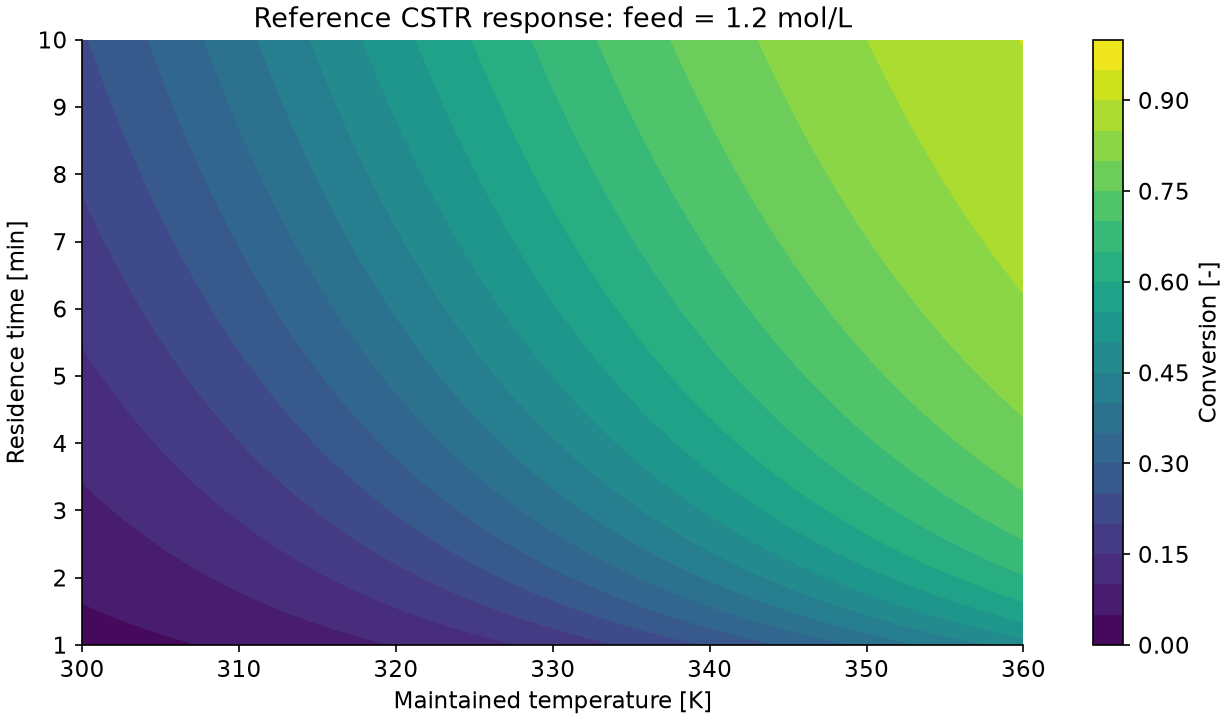

In [7]:
figure = plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(Path("week01-results") / "conversion-map.png"))
plt.axis("off")
plt.show()


### Held-out parity plots / 독립 test parity plot

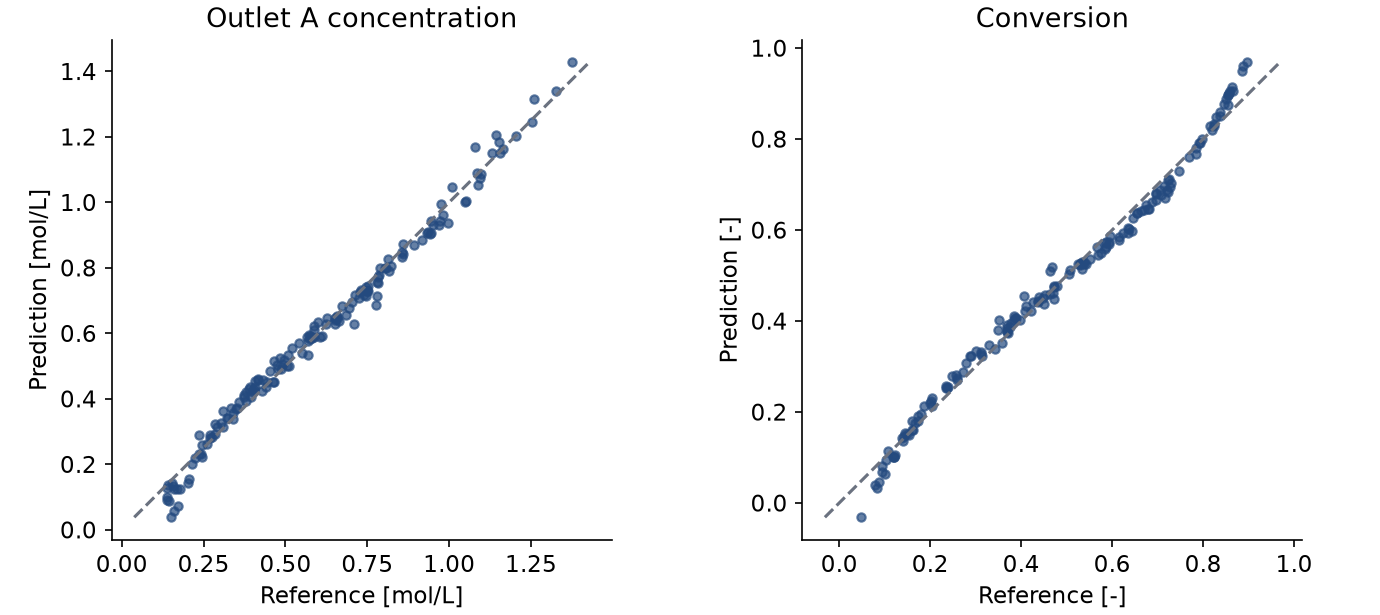

In [8]:
figure = plt.figure(figsize=(10, 6))
plt.imshow(plt.imread(Path("week01-results") / "prediction-check.png"))
plt.axis("off")
plt.show()


## Exercises / 연습문제

1. State the units, fixed assumptions, and input domain. / 단위·고정 가정·입력 영역을 적으세요.
2. Count the two-output regression coefficients. / 두 출력의 회귀 계수를 세어보세요.
3. Change the seed and compare held-out RMSE. / Seed를 바꾸고 독립 RMSE를 비교하세요.
4. Explain why a zero consistency residual need not imply zero prediction error. / 일관성 residual이 0이어도 예측 오차가 0인 것은 아닌 이유를 설명하세요.

Operating selection and dynamic examples are later topics. The standalone script preserves them behind --extensions.
운전점 선택과 동적 예제는 이후 내용이며 독립 스크립트의 --extensions로 실행할 수 있습니다.
